### ***Classification, Hyperparameter, GridSearchCV, RandomSearchCV, Pipeline***

### ***Supermarket Marketing Campaign***

###  ***Context***

***Using the existing campaign data, predict to classify customers who might purchase year end Sale offer.***

#### ***Data Description***

- ***`Response` (target) - 1 if customer accepted the offer in the last campaign, 0 otherwise***
- ***`ID` - Unique ID of each customer***
- ***`Year_Birth` - Age of the customer***
- ***`Complain` - 1 if the customer complained in the last 2 years***
- ***`Dt_Customer` - date of customer's enrollment with the company***
- ***`Education` - customer's level of education***
- ***`Marital` - customer's marital status***
- ***`Kidhome` - number of small children in customer's household***
- ***`Teenhome` - number of teenagers in customer's household***
- ***`Income` - customer's yearly household income***
- ***`MntFishProducts` - the amount spent on fish products in the last 2 years***
- ***`MntMeatProducts` - the amount spent on meat products in the last 2 years***
- ***`MntFruits` - the amount spent on fruits products in the last 2 years***
- ***`MntSweetProducts` - amount spent on sweet products in the last 2 years***
- ***`MntWines` - the amount spent on wine products in the last 2 years***
- ***`MntGoldProds` - the amount spent on gold products in the last 2 years***
- ***`NumDealsPurchases` - number of purchases made with discount***
- ***`NumCatalogPurchases` - number of purchases made using catalog (buying goods to be shipped through the mail)***
- ***`NumStorePurchases` - number of purchases made directly in stores***
- ***`NumWebPurchases` - number of purchases made through the company's website***
- ***`NumWebVisitsMonth` - number of visits to company's website in the last month***
- ***`Recency` - number of days since the last purchase***

### ***Importing Libraries*** 

In [1]:
# To help with reading and manipulating data
import pandas as pd
import numpy as np

# To help with data visualization
%matplotlib inline
import matplotlib.pyplot as plt
import seaborn as sns

# To be used for missing value imputation
from sklearn.impute import SimpleImputer

# To help with model building
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import (
    AdaBoostClassifier,
    GradientBoostingClassifier,
    RandomForestClassifier,
    BaggingClassifier,
)
from xgboost import XGBClassifier

# To get different metric scores, and split data
from sklearn import metrics
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.metrics import (
    f1_score,
    accuracy_score,
    recall_score,
    precision_score,
    confusion_matrix,
    roc_auc_score,
)

# To be used for data scaling and one hot encoding
from sklearn.preprocessing import StandardScaler, MinMaxScaler, OneHotEncoder

# To be used for tuning the model
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV

# To be used for creating pipelines and personalizing them
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import FunctionTransformer

# To define maximum number of columns to be displayed in a dataframe
pd.set_option("display.max_columns", None)

# To supress scientific notations for a dataframe
pd.set_option("display.float_format", lambda x: "%.3f" % x)

# To supress warnings
import warnings
warnings.filterwarnings("ignore")

### ***Dataset Load and Review***

In [2]:
jmd = pd.read_excel("data/34_marketing_data.xlsx")

In [3]:
# let's create a copy of the data
data = jmd.copy()

In [4]:
# let's view the first 5 rows of the data
data.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Response,Complain
0,1826,1970,Graduation,Divorced,84835.000,0,0,6/16/14,0,189,104,379,111,189,218,1,4,4,6,1,1,0
1,1,1961,Graduation,Single,57091.000,0,0,6/15/14,0,464,5,64,7,0,37,1,7,3,7,5,1,0
2,10476,1958,Graduation,Married,67267.000,0,1,5/13/14,0,134,11,59,15,2,30,1,3,2,5,2,0,0
3,1386,1967,Graduation,Together,32474.000,1,1,2014-11-05 00:00:00,0,10,0,1,0,0,0,1,1,0,2,7,0,0
4,5371,1989,Graduation,Single,21474.000,1,0,2014-08-04 00:00:00,0,6,16,24,11,0,34,2,3,1,2,7,1,0


In [5]:
# let's check the data types of the columns in the dataset
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2240 entries, 0 to 2239
Data columns (total 22 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   ID                   2240 non-null   int64  
 1   Year_Birth           2240 non-null   int64  
 2   Education            2240 non-null   object 
 3   Marital_Status       2240 non-null   object 
 4   Income               2216 non-null   float64
 5   Kidhome              2240 non-null   int64  
 6   Teenhome             2240 non-null   int64  
 7   Dt_Customer          2240 non-null   object 
 8   Recency              2240 non-null   int64  
 9   MntWines             2240 non-null   int64  
 10  MntFruits            2240 non-null   int64  
 11  MntMeatProducts      2240 non-null   int64  
 12  MntFishProducts      2240 non-null   int64  
 13  MntSweetProducts     2240 non-null   int64  
 14  MntGoldProds         2240 non-null   int64  
 15  NumDealsPurchases    2240 non-null   i

- ***There are 3 Object and 19 Numerical Variables***
* ***`Income` have missing values***

In [6]:
# Check for duplicate rows in the dataset
data.duplicated().sum()

np.int64(0)

In [7]:
# Percentage of Missing Values
round(data.isnull().sum() / data.isnull().count() * 100, 2)

ID                    0.000
Year_Birth            0.000
Education             0.000
Marital_Status        0.000
Income                1.070
Kidhome               0.000
Teenhome              0.000
Dt_Customer           0.000
Recency               0.000
MntWines              0.000
MntFruits             0.000
MntMeatProducts       0.000
MntFishProducts       0.000
MntSweetProducts      0.000
MntGoldProds          0.000
NumDealsPurchases     0.000
NumWebPurchases       0.000
NumCatalogPurchases   0.000
NumStorePurchases     0.000
NumWebVisitsMonth     0.000
Response              0.000
Complain              0.000
dtype: float64

***Income column has 1.07% missing values. We will further explore to treat them.*** 

#### ***Statistical summary*** 

In [8]:
# let's view the statistical summary of the numerical columns in the data
data.describe().T

,count,mean,std,min,25%,50%,75%,max
ID,2240.000,5592.160,3246.662,0.000,2828.250,5458.500,8427.750,11191.000
Year_Birth,2240.000,1968.806,11.984,1893.000,1959.000,1970.000,1977.000,1996.000
Income,2216.000,52247.251,25173.077,1730.000,35303.000,51381.500,68522.000,666666.000
Kidhome,2240.000,0.444,0.538,0.000,0.000,0.000,1.000,2.000
Teenhome,2240.000,0.506,0.545,0.000,0.000,0.000,1.000,2.000
Recency,2240.000,49.109,28.962,0.000,24.000,49.000,74.000,99.000
MntWines,2240.000,303.936,336.597,0.000,23.750,173.500,504.250,1493.000
MntFruits,2240.000,26.302,39.773,0.000,1.000,8.000,33.000,199.000
MntMeatProducts,2240.000,166.950,225.715,0.000,16.000,67.000,232.000,1725.000
MntFishProducts,2240.000,37.525,54.629,0.000,3.000,12.000,50.000,259.000


####  ***Observations*** 
- ***`Year_Birth` has a large range of values i.e. 1893 to 1996 that indicates the customers of age above 18. However, The birth year <=1900 for some users, while the year of campaign we are considering is 2016. It's very unlikely that the person is alive. It may be a reporting error. Need further checking***
- ***`Income` has a max value of 666,666 which is far greater than the mean and could be an outlier.***
- ***Columns - `Income, MntFruits, MntWines, MntMeatProducts, MntFishProducts, MntSweetProducts` might have outliers on the right end as there is a large difference between 75th percentile and maximum values.***
- ***Recency has an approx equal mean and median which is equal to 49 days.***
- ***Highest mean amount spent per customer in the last two years is on wines (approx 304), followed by meat products (approx 167).***

In [9]:
## Let's create a list of numerical and categorical columns
categorical_cols = ["Education", "Marital_Status"]

numerical_cols = [
    "Year_Birth",
    "Income",
    "Kidhome",
    "Teenhome",
    "Recency",
    "MntWines",
    "MntFruits",
    "MntMeatProducts",
    "MntFishProducts",
    "MntSweetProducts",
    "MntGoldProds",
    "NumDealsPurchases",
    "NumWebPurchases",
    "NumCatalogPurchases",
    "NumStorePurchases",
    "NumWebVisitsMonth",
    "Complain",
]

#### ***Univariate EDA on Numerical variables***  

***Helper Functions***

In [10]:
# Function to create a histogram and boxplot combined for visualization of numerical features for Univariate Analysis
def num_analysis_hist_box(data, feature, figsize=(10, 5)):
    """
    Boxplot and histogram combined
    data: dataframe
    feature: dataframe column
    figsize: size of figure (default (10,5))
    """
    f2, (ax_box2, ax_hist2) = plt.subplots(
        nrows=2,  # Number of rows of the subplot grid= 2
        sharex=True,  # x-axis will be shared among all subplots
        gridspec_kw={"height_ratios": (0.25, 0.75)},
        figsize=figsize)  # creating the 2 subplots
    
    sns.boxplot(data=data, x=feature, ax=ax_box2, showmeans=True, color="lightgreen")  # boxplot will be created and a star will indicate the mean value of the column
    sns.histplot(data=data, x=feature, kde=True, ax=ax_hist2, color='skyblue')  # For histogram
    
    ax_hist2.axvline(data[feature].mean(), color="green", linestyle="--")  # Add mean to the histogram
    ax_hist2.axvline(data[feature].median(), color="black", linestyle="-")  # Add median to the histogram

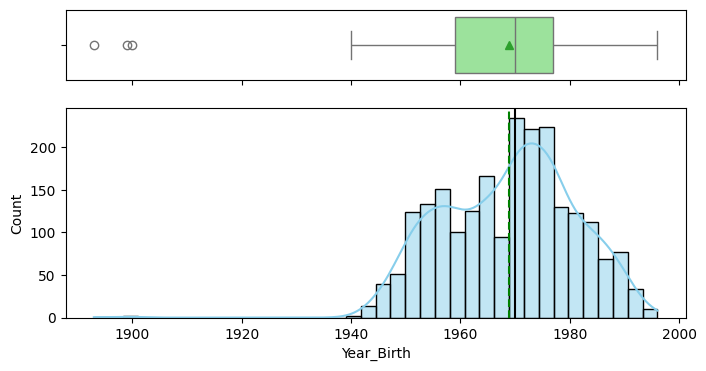

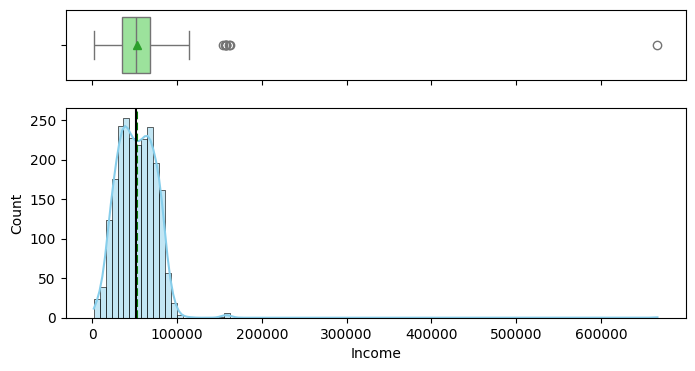

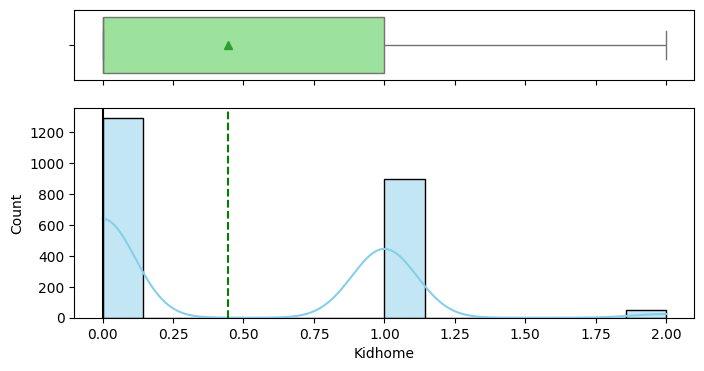

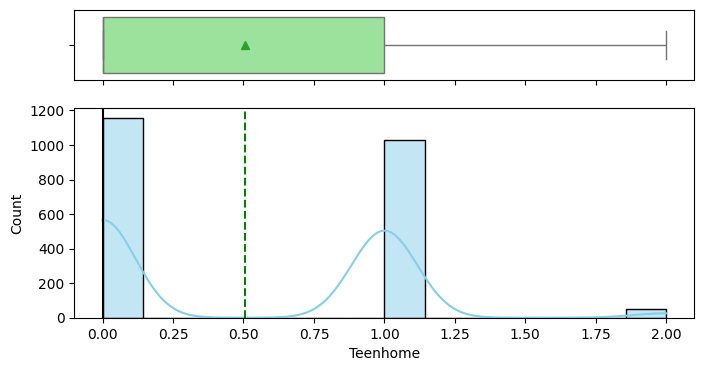

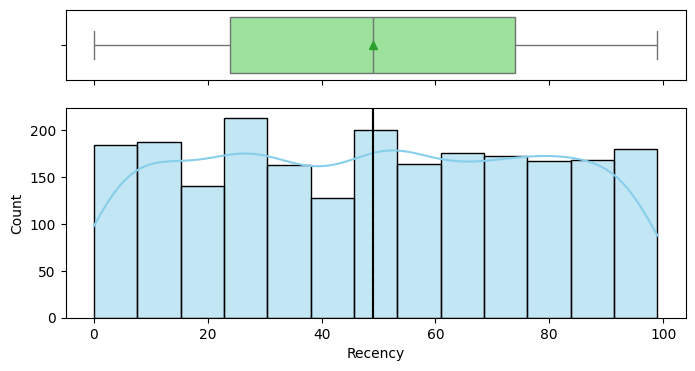

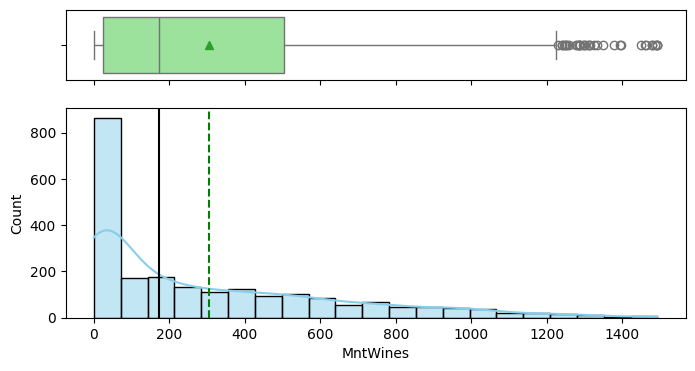

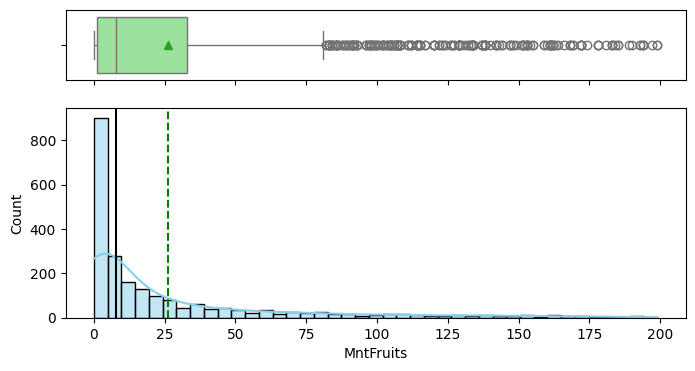

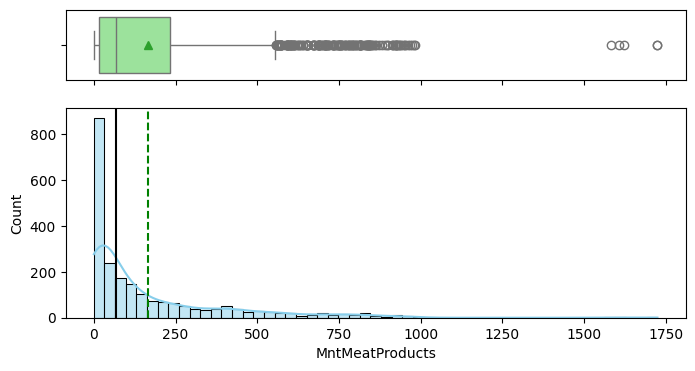

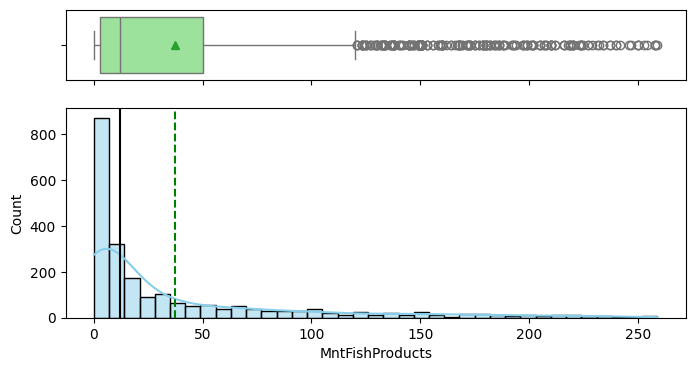

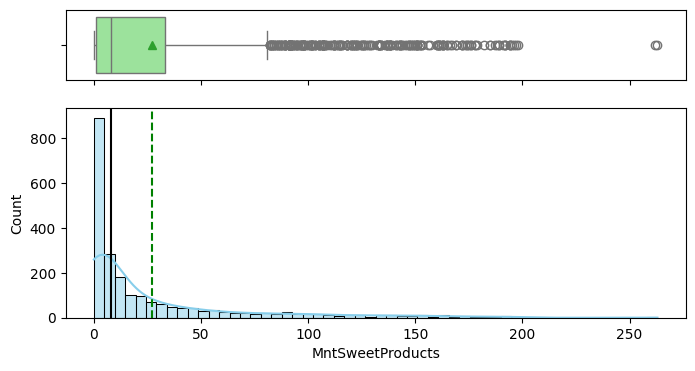

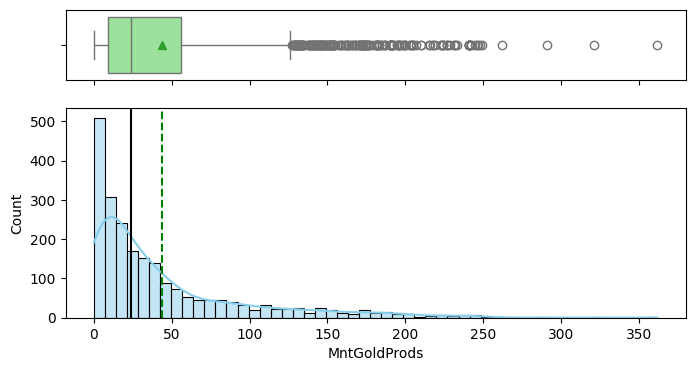

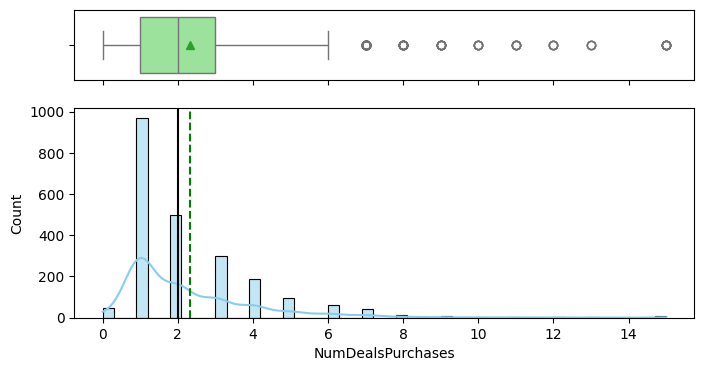

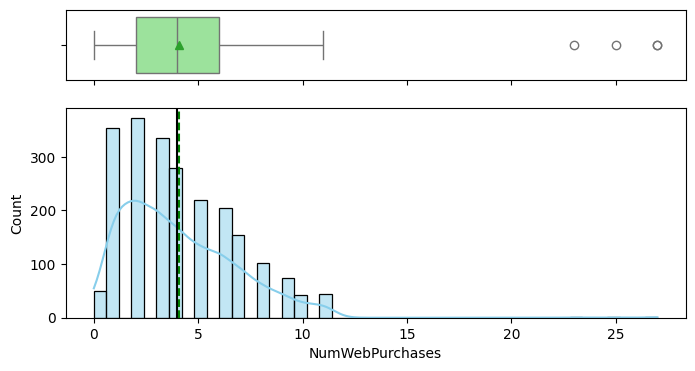

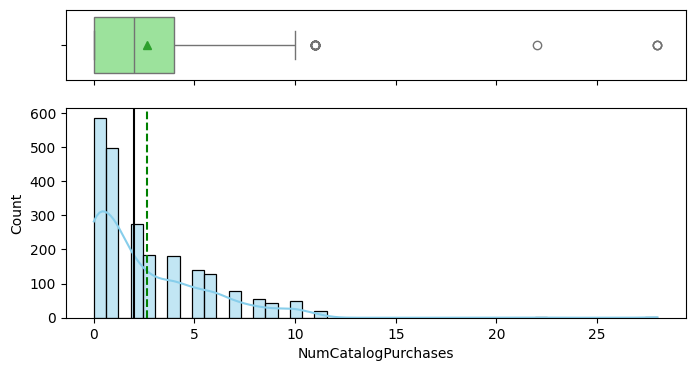

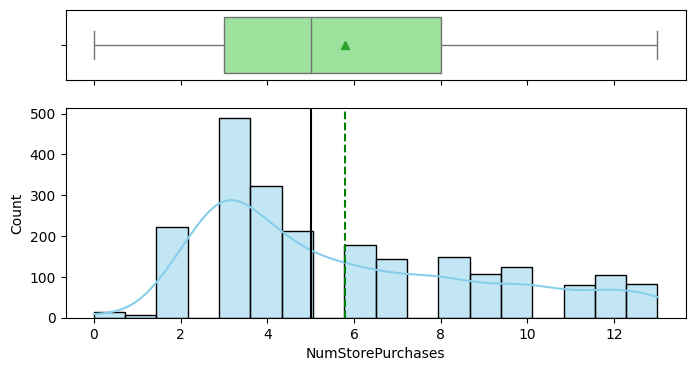

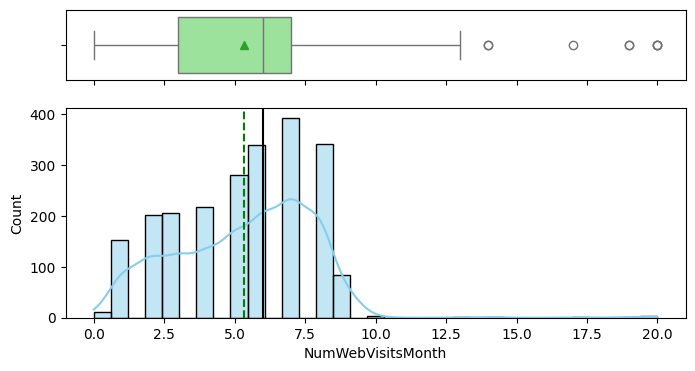

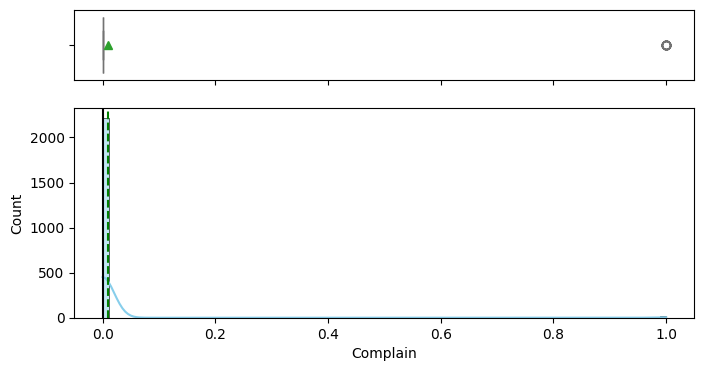

In [11]:
for feature in numerical_cols:
    num_analysis_hist_box(data, feature, figsize=(8, 4))

#### ***Observations***  
* ***The `Year Birth` distribution is close to normal with majarity of the people born in 1968. There are few born in around 1900, which seems unlikely given the box plot***
* ***The distribution of `Income` is skewed indicating that most of the customers have 100000 Income. Some of the customers have >600000 Income as well.***
* ***`Kidhome` and `Teenhome` have three unique values i.e 0,1,2. Most of the customers have 0 or 1 kids or teenagers at home.*** 
* ***The distribution of `Recency` is fairly symmetric and uniformly distributed.*** 
* ***`MntWines, MntFruits, MntMeatProducts, MntFishProduct, MntSweetProducts, MntGoldProducts` tend to have a skewed distribution. On comparing the amount spend on each product, majority of the customers spend more amount on wines and meat products.***
* ***Majority of the customers have 2 or less than 2 deal purchases. We can see that there some extreme observations in the variable. This represents the real market trend.***
* ***On an average, `NumWebPurchases` made by the customers is aroud 4.*** 
* ***The average `NumCatalogPurchases` is found to be around to be around 2 indicating that customers are less likely to buy goods using catalog.*** 
* ***We can see various peaks in the `NumStorePurchases` and highest one can be observed around 3 and 4 indicating that supermarket gets almost an equal amount of purchases from store and their website.*** 
* ***The highest peak in the `NumWebVisitsMonth` can be observed around 6 which indicates that customers do spend time on the website.*** 
* ***Most of the customers do not file a `complain` which is a good sign for the company. This shows that the customers are happy with the service provided.***  

#### ***Univariate EDA on Categorical variables***  

***Helper Functions***

In [12]:
# Function to plot count and percentage barplots side by side for categorical features for Univariate Analysis
def cat_analysis_count_and_perct(data, column, figsize=(12, 5)):
    """
    Plots two countplots side by side: one with count labels, one with percentage labels.
    Args:
        data (pd.DataFrame): The DataFrame containing the data.
        column (str): The column to plot.
        figsize (tuple): Figure size for the plots.
    """
    fig, axes = plt.subplots(1, 2, figsize=figsize)
    categories = data[column].value_counts().index
    total = len(data)
    
    # Countplot with count labels
    ax1 = sns.countplot(data=data, x=column, hue=column, order=categories, ax=axes[0], palette='Set2')
    axes[0].set_title('Counts per ' + column)
    axes[0].set_xlabel(column)
    axes[0].set_ylabel('Count')
    axes[0].tick_params(axis='x', rotation=90)
    for p in ax1.patches:
        count = int(p.get_height())
        ax1.annotate(str(count), (p.get_x() + p.get_width() / 2, p.get_height()),
                     ha='center', va='bottom', fontsize=10, color='black')
    
    # Countplot with percentage labels
    ax2 = sns.countplot(data=data, x=column, hue=column, order=categories, ax=axes[1], palette='Set2')
    axes[1].set_title('Percentage per ' + column)
    axes[1].set_xlabel(column)
    axes[1].set_ylabel('Percentage')
    axes[1].tick_params(axis='x', rotation=90)
    for p in ax2.patches:
        percent = 100 * p.get_height() / total
        ax2.annotate(f'{percent:.1f}%', (p.get_x() + p.get_width() / 2, p.get_height()),
                     ha='center', va='bottom', fontsize=10, color='blue')
    
    plt.tight_layout()
    plt.show()

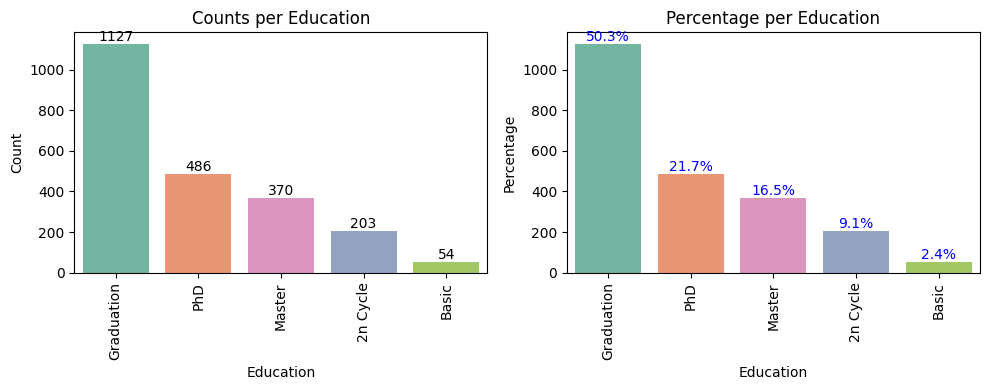

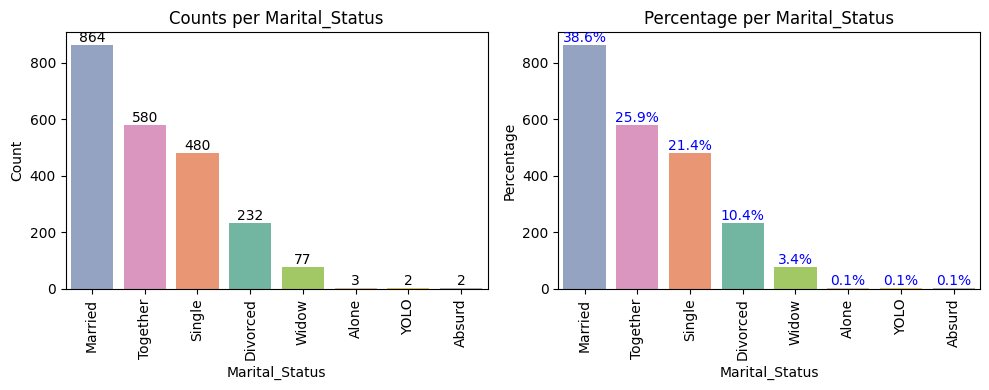

In [13]:
for feature in categorical_cols:
    cat_analysis_count_and_perct(data, feature, figsize=(10, 4))

#### ***Observations*** 
* ***`Education` of most of the customers is graduation level. Very few have a basic education. 2n cycle education is similar to Master. Hence, we will merge these two categories to reduce the number of category.*** 
* ***The `Marital Status` of majority of the customers are married. YOLO, Alone and Absurd is similar to single. Hence, we will merge these categories to reduce the number of category.***


#### ***Bivariate EDA***  

#### ***Correlation Plot*** 

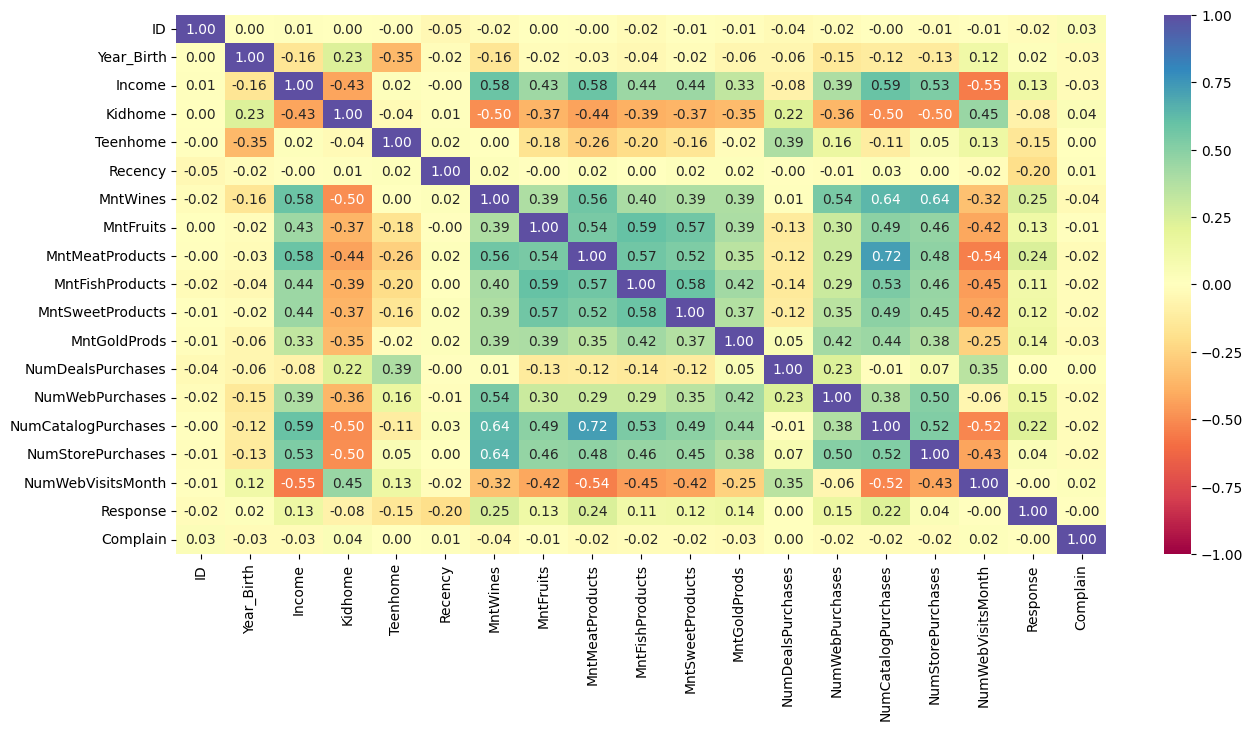

In [14]:
plt.figure(figsize=(15, 7))
sns.heatmap(data.select_dtypes(include='number').corr(), annot=True, vmin=-1, vmax=1, fmt=".2f", cmap="Spectral")
plt.show()

####  ***Observations*** 
* ***`MntMeatProducts` and `NumCatalogPurchases` are highly correlated that shows most people buy meat products via catalog.*** 
* ***`MntWines` and `NumStorePurchases` are correlated indicating that customers buy wines by personally visiting to the store.*** 
* ***`Income` and `NumWebVisitsMonth` are negatively correlated that shows customers with high income do not make web visits.*** 
* ***Number of purchases is positively correlated with income which can be expected as customers with higher income might spend more than customers with lower income.***
* ***`Response` seems somewhat positively correlated with `NumCatalogPurchases`, `MntWines` and negatively with `Recency`***


***Let's check the relationship between response and Numerical variables***

In [15]:
# Mean of numerical variables grouped by attrition
data.groupby(["Response"])[numerical_cols].mean()

,Year_Birth,Income,Kidhome,Teenhome,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain
Response,,,,,,,,,,,,,,,,,
0,1968.699,50839.133,0.462,0.541,51.515,269.104,24.217,144.624,34.980,25.035,40.969,2.323,3.912,2.392,5.737,5.321,0.009
1,1969.416,60209.676,0.341,0.305,35.383,502.704,38.204,294.353,52.051,38.635,61.446,2.335,5.072,4.204,6.096,5.293,0.009


#### ***Observations*** 
* ***People with high income are more likely to accept the offer in the campaign which is fair enough.*** 
* ***Customers who spent more money on wines are more likely to take the offer.***
* ***Customers who are making more visits to the store and the website have high chance of taking the offer.*** 

***Let's check the relationship between response and Categorical variables***

***Helper Function***

In [16]:
# Function to plot target distribution by category with percentage labels on stacked bar segments
def target_distribution_by_category(data, x_col, hue_col, colormap='tab20', figsize=(6, 4), title=None):
    """
    Plots a stacked bar chart showing percentage distribution of hue_col within each x_col category,
    with percentage labels on each segment.
    """
    # Group and calculate percentages
    grouped = data.groupby([x_col, hue_col]).size().unstack(fill_value=0)
    percentages = grouped.div(grouped.sum(axis=1), axis=0) * 100

    # Plot
    ax = percentages.plot(kind='bar', stacked=True, figsize=figsize, colormap=colormap)

    # Add percentage labels
    for i, (index, row) in enumerate(percentages.iterrows()):
        cum_height = 0
        for j, value in enumerate(row):
            if value > 0:
                ax.text(
                    i,                      # x position
                    cum_height + value / 2, # y position (middle of the bar segment)
                    f'{value:.1f}%',        # label text
                    ha='center', va='center', fontsize=8, color='white'
                )
                cum_height += value

    plt.ylabel('Percentage')
    plt.title(title or f'{x_col} Distribution by {hue_col} (Stacked Percentage)')
    plt.legend(title=hue_col, bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.tight_layout()
    plt.show()

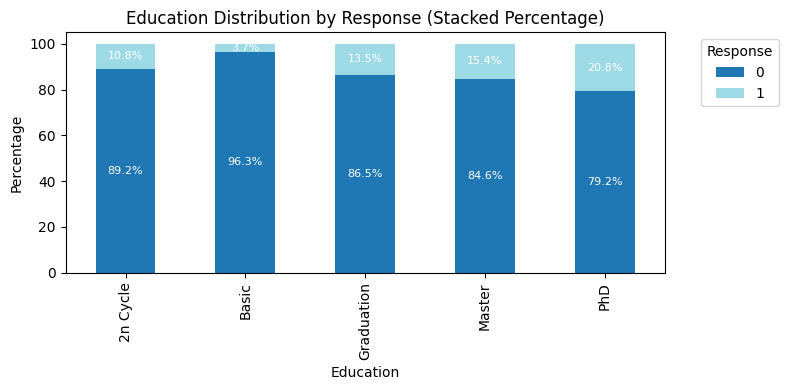

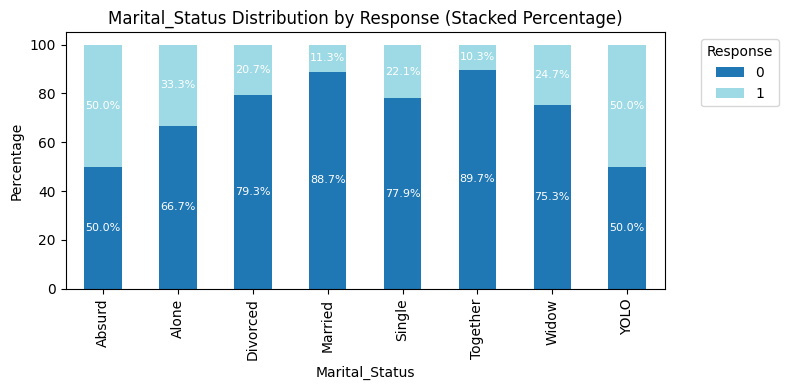

In [17]:
for feature in categorical_cols:
    target_distribution_by_category(data, feature, 'Response',figsize=(8, 4))

#### ***Observations*** 
* ***Customers with higher Education are more likely to take the offer.***
* ***Single customers are more likely to take the offer than married customers. Married customers are less like to take the offer indicating that they might have more expenses than a single customer and they don't find a need to take the offer.*** 

### ***Data Preprocessing***  

***Dropping `ID`***

In [18]:
# Dropping ID column as it is not going to be useful for analysis
data.drop(columns=["ID"], inplace=True)

* Adding age of the customers to the data using given birth years

***Adding Age from `Year_Birth`***

In [19]:
# To calculate age we'll subtract the year 2016 because variables account for the last 2 years
# and we have customers registered till 2014 only
# We need to convert strings values to dates first to use subtraction
data["Age"] = 2016 - pd.to_datetime(data["Year_Birth"], format="%Y").apply(lambda x: x.year)

data["Age"].sort_values()

1824     20
562      20
1298     21
1467     21
1468     21
       ... 
1740     75
2171     76
2233    116
827     117
513     123
Name: Age, Length: 2240, dtype: int64

- ***We can see that there are 3 observations with ages greater than 100 i.e. 116, 117 and 123 which is highly unlikely to be true.***
- ***We can drop the observations with age greater than 100***

In [20]:
data[data["Age"] > 100]

,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Response,Complain,Age
513,1893,2n Cycle,Single,60182.000,0,1,5/17/14,23,8,0,5,7,0,2,1,1,0,2,4,0,0,123
827,1899,PhD,Together,83532.000,0,0,9/26/13,36,755,144,562,104,64,224,1,4,6,4,1,0,0,117
2233,1900,2n Cycle,Divorced,36640.000,1,0,9/26/13,99,15,6,8,7,4,25,1,2,1,2,5,0,1,116


- ***The Year_Birth for these 3 observations seems to be incorrect***
- ***Replacing them with some other values might not be the best thing to do***
- ***We will drop these 3 observations***

In [21]:
# Dropping the 3 observations with age > 100
data.drop(data[data["Age"] > 100].index, inplace=True)

***Using Dt_Customer to add features to the data***

In [22]:
# The feature Dt_Customer represents dates of the customer’s enrollment with the company.
# Let's convert this to DateTime format
data["Dt_Customer"] = pd.to_datetime(data["Dt_Customer"])

In [23]:
# Extracting registration year from the date
data["Reg_year"] = data["Dt_Customer"].apply(lambda x: x.year)

# Extracting registration quarter from the date
data["Reg_quarter"] = data["Dt_Customer"].apply(lambda x: x.quarter)

# Extracting registration month from the date
data["Reg_month"] = data["Dt_Customer"].apply(lambda x: x.month)

# Extracting registration week from the date
data["Reg_week"] = data["Dt_Customer"].apply(lambda x: x.day // 7)

***Replacing some categories in Education and marital status column***

In [24]:
# Replacing 2n Cycle with Master
data["Education"] = data["Education"].replace("2n Cycle", "Master")

In [25]:
# Replacing YOLO, Alone, Absurd with single and Together with Married
data["Marital_Status"] = data["Marital_Status"].replace(["YOLO", "Alone", "Absurd"], "Single")
data["Marital_Status"] = data["Marital_Status"].replace(["Together"], "Married")

In [26]:
# Dropping birth year and Dt_Customer columns
data.drop(columns=["Year_Birth", "Dt_Customer", "Reg_quarter"], inplace=True)

#### ***Data Preparation for Modeling***

In [27]:
data1 = data.copy()

***Separating target variable and other variables***

In [28]:
X = data1.drop(columns="Response")
Y = data1["Response"]

***Splitting the data into train/test***

In [29]:
# Splitting data into training, validation and test set:
# first we split data into 2 parts, say temporary and test

X_train, X_test, y_train, y_test = train_test_split(X, Y, test_size=0.3, random_state=1, stratify=Y)

print(X_train.shape, X_test.shape)

(1565, 22) (672, 22)


In [30]:
data1.isnull().sum()

Education               0
Marital_Status          0
Income                 24
Kidhome                 0
Teenhome                0
Recency                 0
MntWines                0
MntFruits               0
MntMeatProducts         0
MntFishProducts         0
MntSweetProducts        0
MntGoldProds            0
NumDealsPurchases       0
NumWebPurchases         0
NumCatalogPurchases     0
NumStorePurchases       0
NumWebVisitsMonth       0
Response                0
Complain                0
Age                     0
Reg_year                0
Reg_month               0
Reg_week                0
dtype: int64

### ***Missing-Value Treatment***

***We will use median to impute missing values in Income column. We have decided to impute this variable with median as data is skewed.*** 

***`SimpleImputer` provides various basic strategies to impute the missing values. We fit the imputer on the train set and then impute the nulls in the different datasets i.e train, test and validation***

In [31]:
imputer = SimpleImputer(strategy="median")
X_train['Income'] = imputer.fit_transform(X_train[['Income']])

X_test['Income'] = imputer.transform(X_test[['Income']])

#### ***Encoding***

In [32]:
X_train = pd.get_dummies(data=X_train, drop_first=True)
X_test = pd.get_dummies(data=X_test, drop_first=True)

### ***Model evaluation criterion:***

#### ***Model can make wrong predictions as:***
***1. Predicting a customer will buy the product and the customer doesn't buy - Loss of resources - False Positive***<br>
***2. Predicting a customer will not buy the product and the customer buys - Loss of opportunity - False Negative***

#### ***Which case is more important?*** 
***Company should target customers who will buy, and for that we have to reduce False Negative. Recall should be maximized***

### ***Model Building with Default Parameters and checking their Cross Validation Scores***

In [33]:
models = []  # Empty list to store all the models

# Appending models into the list
models.append(("Bagging", BaggingClassifier(random_state=1)))
models.append(("Random forest", RandomForestClassifier(random_state=1)))
models.append(("GBM", GradientBoostingClassifier(random_state=1)))
models.append(("Adaboost", AdaBoostClassifier(random_state=1)))
models.append(("Xgboost", XGBClassifier(random_state=1, eval_metric="logloss")))

results = []  # Empty list to store all model's CV scores
names = []  # Empty list to store name of the models

# loop through all models to get the mean cross validated score
print("\n" "Cross-Validation Performance:" "\n")

for name, model in models:
    scoring = "recall"
    kfold = StratifiedKFold(n_splits=5, shuffle=True, random_state=1)  # Setting number of splits equal to 5
    
    cv_result = cross_val_score(estimator=model, X=X_train, y=y_train, scoring=scoring, cv=kfold)

    results.append(cv_result)
    names.append(name)
    print("{}: {}".format(name, round(cv_result.mean(),3)))

print("\n" "Training Performance:" "\n")

for name, model in models:
    model.fit(X_train, y_train)
    scores = recall_score(y_train, model.predict(X_train))
    print("{}: {}".format(name, round(scores, 3)))


Cross-Validation Performance:

Bagging: 0.324
Random forest: 0.26
GBM: 0.341
Adaboost: 0.222
Xgboost: 0.363

Training Performance:

Bagging: 0.897
Random forest: 0.974
GBM: 0.637
Adaboost: 0.329
Xgboost: 0.974


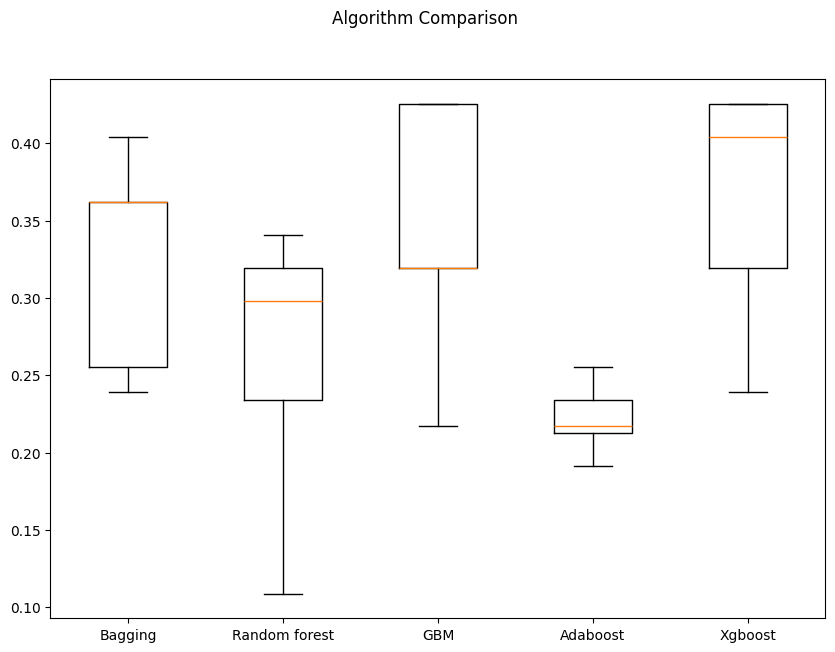

In [34]:
# Plotting boxplots for CV scores of all models defined above
fig = plt.figure(figsize=(10, 7))

fig.suptitle("Algorithm Comparison")
ax = fig.add_subplot(111)

plt.boxplot(results)
ax.set_xticklabels(names)

plt.show()

***We will try Hyperparameter Tuning on `Gradient Boosting` and `XGBoost` as they both have higher cross validation scores***

***Helper Functions***

In [35]:
# defining a function to compute different metrics to check performance of a classification model built using sklearn
def model_performance_classification_sklearn(model, predictors, target):
    """
    Function to compute different metrics to check classification model performance

    model: classifier
    predictors: independent variables
    target: dependent variable
    """

    # predicting using the independent variables
    pred = model.predict(predictors)

    acc = accuracy_score(target, pred)  # to compute Accuracy
    recall = recall_score(target, pred)  # to compute Recall
    precision = precision_score(target, pred)  # to compute Precision
    f1 = f1_score(target, pred)  # to compute F1-score

    # creating a dataframe of metrics
    df_perf = pd.DataFrame(
        {"Accuracy": acc, "Recall": recall, "Precision": precision, "F1": f1,},
        index=[0],
    )

    return df_perf

In [36]:
def confusion_matrix_sklearn(model, predictors, y_actual):
    """
    Generates a labeled confusion matrix heatmap.

    Parameters:
    - model: trained classifier
    - predictors: feature matrix to predict on (can be train, test, or validation)
    - y_actual: true labels corresponding to X
    """
    # Predict labels
    y_predict = model.predict(predictors)

    # Compute confusion matrix
    cm = confusion_matrix(y_actual, y_predict, labels=[0, 1])
    df_cm = pd.DataFrame(cm, index=["Actual - No", "Actual - Yes"],
                             columns=["Predicted - No", "Predicted - Yes"])

    # Annotate with counts and percentages
    group_counts = [f"{value:0.0f}" for value in cm.flatten()]
    group_percentages = [f"{value:.2%}" for value in cm.flatten() / np.sum(cm)]
    labels = [f"{count}\n{percent}" for count, percent in zip(group_counts, group_percentages)]
    labels = np.asarray(labels).reshape(cm.shape)

    # Plot heatmap
    plt.figure(figsize=(6, 4))
    sns.heatmap(df_cm, annot=labels, fmt='', cmap='Blues')
    plt.ylabel('Actual label')
    plt.xlabel('Predicted label')
    plt.title('Confusion Matrix')
    plt.tight_layout()
    plt.show()

### ***Gradient Boosting with Hyperparameter***

***Gradient Boosting with Grid Search***

In [37]:
%%time 

# defining model
model = GradientBoostingClassifier(random_state=1)

# Parameter grid to pass in GridSearchCV
param_grid = {
    'n_estimators': [100, 200, 300],               # Number of boosting rounds
    'learning_rate': [0.01, 0.05, 0.1],            # Shrinks contribution of each tree
    'max_depth': [3, 5, 7],                        # Controls tree complexity
    'min_samples_split': [2, 5, 10],               # Minimum samples to split a node
    'min_samples_leaf': [1, 3, 5],                 # Minimum samples at a leaf node
    'subsample': [0.6, 0.8, 1.0],                  # Fraction of samples per tree
    'max_features': ['sqrt', 'log2', None],        # Features considered per split
    'loss': ['deviance', 'exponential']            # Loss function for classification
}

# param_grid = {
#     "n_estimators": np.arange(10, 110, 10),
#     "learning_rate": [0.1, 0.01, 0.2, 0.05, 1],
#     "base_estimator": [
#         DecisionTreeClassifier(max_depth=1, random_state=1),
#         DecisionTreeClassifier(max_depth=2, random_state=1),
#         DecisionTreeClassifier(max_depth=3, random_state=1),
#     ],
# }

# Type of scoring used to compare parameter combinations
scorer = metrics.make_scorer(metrics.recall_score)

# Calling GridSearchCV
grid_cv = GridSearchCV(estimator=model, param_grid=param_grid, scoring=scorer, cv=5, n_jobs = -1)

# Fitting parameters in GridSearchCV
grid_cv.fit(X_train, y_train)

print("Best Parameters:{} \nScore: {}".format(grid_cv.best_params_, grid_cv.best_score_))

Best Parameters:{'learning_rate': 0.1, 'loss': 'exponential', 'max_depth': 5, 'max_features': None, 'min_samples_leaf': 5, 'min_samples_split': 2, 'n_estimators': 300, 'subsample': 0.6} 
Score: 0.4399629972247919
CPU times: total: 25.5 s
Wall time: 34min 44s


In [38]:
# building model with best parameters
gb_model = GradientBoostingClassifier(
    learning_rate=0.1,
    loss='exponential',
    max_depth=5,
    max_features=None,
    min_samples_leaf=5,
    min_samples_split=2,
    n_estimators=300,
    subsample=0.6,
    random_state=42
)

# adb_tuned1 = AdaBoostClassifier(
#     n_estimators=70,
#     learning_rate=1,
#     random_state=1,
#     base_estimator=DecisionTreeClassifier(max_depth=2, random_state=1),
# )

# Fit the model on training data
gb_model.fit(X_train, y_train)

,loss,'exponential'
,learning_rate,0.1
,n_estimators,300
,subsample,0.6
,criterion,'friedman_mse'
,min_samples_split,2
,min_samples_leaf,5
,min_weight_fraction_leaf,0.0
,max_depth,5
,min_impurity_decrease,0.0
,init,None


Training performance:
   Accuracy  Recall  Precision    F1
0     0.994   0.974      0.983 0.979
*************************************


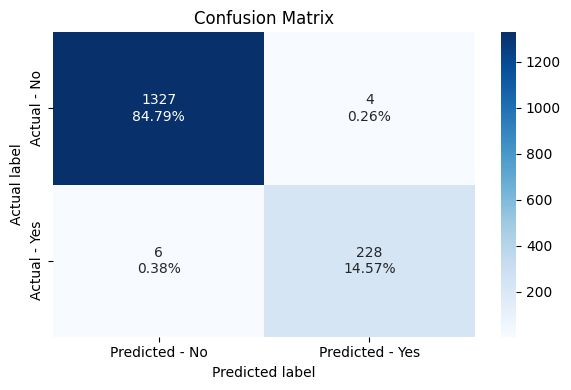

In [39]:
# Calculating different metrics on train set
GBD_grid_train = model_performance_classification_sklearn(gb_model, X_train, y_train)
print("Training performance:")
print(GBD_grid_train)

print("*************************************")

# creating confusion matrix
confusion_matrix_sklearn(gb_model, X_train, y_train)

***Model is still overfitting it seems***

***Gradient Boosting with Randomized Search***

In [40]:
%%time 

# defining model
model = GradientBoostingClassifier(random_state=1)

# Parameter grid to pass in GridSearchCV
param_grid = {
    'n_estimators': [100, 200, 300],               # Number of boosting rounds
    'learning_rate': [0.01, 0.05, 0.1],            # Shrinks contribution of each tree
    'max_depth': [3, 5, 7],                        # Controls tree complexity
    'min_samples_split': [2, 5, 10],               # Minimum samples to split a node
    'min_samples_leaf': [1, 3, 5],                 # Minimum samples at a leaf node
    'subsample': [0.6, 0.8, 1.0],                  # Fraction of samples per tree
    'max_features': ['sqrt', 'log2', None],        # Features considered per split
    'loss': ['deviance', 'exponential']            # Loss function for classification
}

# Type of scoring used to compare parameter combinations
scorer = metrics.make_scorer(metrics.recall_score)

#Calling RandomizedSearchCV
randomized_cv = RandomizedSearchCV(estimator=model, param_distributions=param_grid, n_jobs = -1, n_iter=50, scoring=scorer, cv=5, random_state=1)

#Fitting parameters in RandomizedSearchCV
randomized_cv.fit(X_train,y_train)

print("Best parameters are {} with CV score={}:" .format(randomized_cv.best_params_,randomized_cv.best_score_))

Best parameters are {'subsample': 0.8, 'n_estimators': 300, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_features': 'log2', 'max_depth': 3, 'loss': 'exponential', 'learning_rate': 0.1} with CV score=0.3844588344125809:
CPU times: total: 1.12 s
Wall time: 32 s


In [41]:
# building model with best parameters
gb_model2 = GradientBoostingClassifier(
    learning_rate=0.1,
    loss='exponential',
    max_depth=3,
    max_features='log2',
    min_samples_leaf=1,
    min_samples_split=2,
    n_estimators=300,
    subsample=0.8,
    random_state=42
)

# Fit the model on training data
gb_model2.fit(X_train, y_train)

,loss,'exponential'
,learning_rate,0.1
,n_estimators,300
,subsample,0.8
,criterion,'friedman_mse'
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_depth,3
,min_impurity_decrease,0.0
,init,None


**Checking model performance**

Training performance:
   Accuracy  Recall  Precision    F1
0     0.970   0.825      0.970 0.891
*************************************


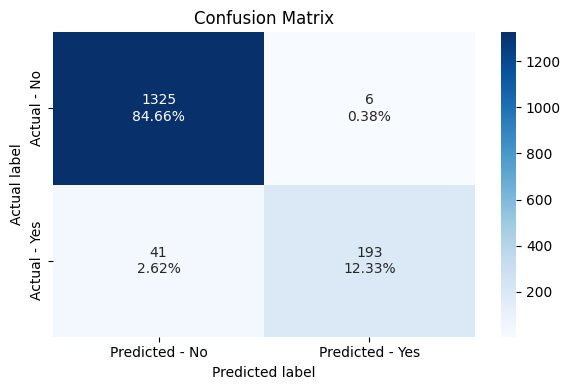

In [42]:
# Calculating different metrics on train set
GBD_random_train = model_performance_classification_sklearn(
    gb_model2, X_train, y_train
)
print("Training performance:")
print(GBD_random_train)


print("*************************************")

# creating confusion matrix
confusion_matrix_sklearn(gb_model2, X_train, y_train)

***Randomized Search took significantly less time, training recall is not so high***

### ***XGBoost with Hyperparameter*** 

***XGBoost with Grid Search***

In [43]:
%%time 

#defining model
model = XGBClassifier(random_state=1,eval_metric='logloss')

#Parameter grid to pass in GridSearchCV
param_grid={'n_estimators':np.arange(50,150,50),
            'scale_pos_weight':[2,5,10],
            'learning_rate':[0.01,0.1,0.2,0.05],
            'gamma':[0,1,3,5],
            'subsample':[0.8,0.9,1],
            'max_depth':np.arange(1,5,1),
            'reg_lambda':[5,10]}


# Type of scoring used to compare parameter combinations
# scorer = metrics.make_scorer(metrics.recall_score) # I tried recall and got all positive, now I am going to try f1
scorer = metrics.make_scorer(metrics.f1_score)

#Calling GridSearchCV
grid_cv = GridSearchCV(estimator=model, param_grid=param_grid, scoring=scorer, cv=5, n_jobs = -1)

#Fitting parameters in GridSearchCV
grid_cv.fit(X_train,y_train)


print("Best parameters are {} with CV score={}:" .format(grid_cv.best_params_,grid_cv.best_score_))

Best parameters are {'gamma': 3, 'learning_rate': 0.2, 'max_depth': np.int64(4), 'n_estimators': np.int64(50), 'reg_lambda': 10, 'scale_pos_weight': 5, 'subsample': 0.9} with CV score=0.5887802670977647:
CPU times: total: 15.8 s
Wall time: 2min 40s


In [44]:
# building model with best parameters
xgb_tuned1 = XGBClassifier(
    random_state=1,
    n_estimators=50,
    scale_pos_weight=5,
    subsample=0.9,
    learning_rate=0.02,
    gamma=3,
    eval_metric="logloss",
    reg_lambda=10,
    max_depth=4,
)

# Fit the model on training data
xgb_tuned1.fit(X_train, y_train)

,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,'logloss'


Training performance:
   Accuracy  Recall  Precision    F1
0     0.836   0.821      0.472 0.599
*************************************


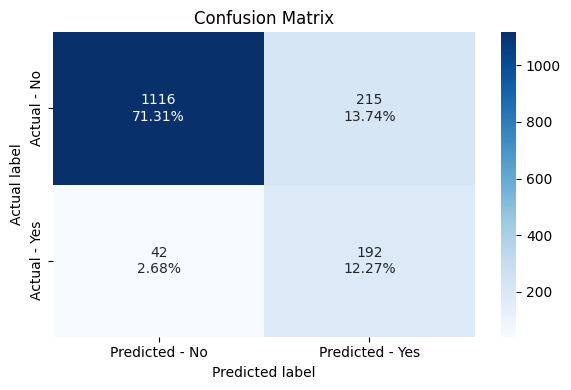

In [45]:
# Calculating different metrics on train set
xgboost_grid_train = model_performance_classification_sklearn(xgb_tuned1, X_train, y_train)
print("Training performance:")
print(xgboost_grid_train)

print("*************************************")


# creating confusion matrix
confusion_matrix_sklearn(xgb_tuned1, X_train, y_train)

- ***When Scoring was Recall, Model predicted all as Yes***
- ***Changed the scoring to f1-score, Model prediction looks reasonable***

***XGBoost with Randomized Search***

In [46]:
%%time

# defining model
model = XGBClassifier(random_state=1,eval_metric='logloss')

# Parameter grid to pass in RandomizedSearchCV
param_grid={'n_estimators':np.arange(50,150,50),
            'scale_pos_weight':[2,5,10],
            'learning_rate':[0.01,0.1,0.2,0.05],
            'gamma':[0,1,3,5],
            'subsample':[0.8,0.9,1],
            'max_depth':np.arange(1,5,1),
            'reg_lambda':[5,10]}

# Type of scoring used to compare parameter combinations
# scorer = metrics.make_scorer(metrics.recall_score)

scorer = metrics.make_scorer(metrics.f1_score)

#Calling RandomizedSearchCV
xgb_tuned2 = RandomizedSearchCV(estimator=model, param_distributions=param_grid, n_iter=50, scoring=scorer, cv=5, random_state=1, n_jobs = -1)

#Fitting parameters in RandomizedSearchCV
xgb_tuned2.fit(X_train,y_train)

print("Best parameters are {} with CV score={}:" .format(xgb_tuned2.best_params_,xgb_tuned2.best_score_))

Best parameters are {'subsample': 0.9, 'scale_pos_weight': 5, 'reg_lambda': 10, 'n_estimators': np.int64(100), 'max_depth': np.int64(4), 'learning_rate': 0.05, 'gamma': 5} with CV score=0.5673329470179864:
CPU times: total: 453 ms
Wall time: 3.52 s


In [47]:
# building model with best parameters
xgb_tuned2 = XGBClassifier(
    random_state=1,
    n_estimators=100,
    scale_pos_weight=5,
    gamma=3,
    subsample=0.9,
    learning_rate=0.02,
    eval_metric="logloss",
    max_depth=4,
    reg_lambda=10,
)
# Fit the model on training data
xgb_tuned2.fit(X_train, y_train)

,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,'logloss'


**Checking model performance**

Training performance:
   Accuracy  Recall  Precision    F1
0     0.854   0.893      0.506 0.646
*************************************


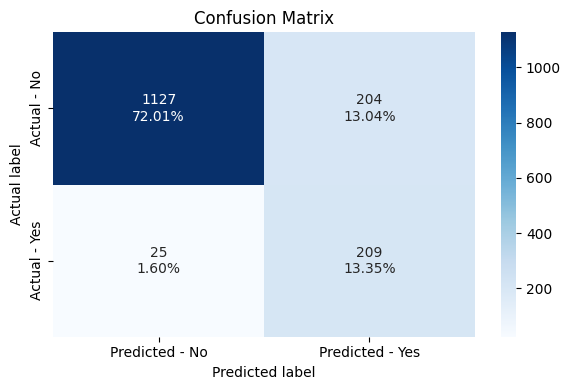

In [48]:
# Calculating different metrics on train set
xgboost_random_train = model_performance_classification_sklearn(xgb_tuned2, X_train, y_train)
print("Training performance:")
print(xgboost_random_train)

print("*************************************")


# creating confusion matrix
confusion_matrix_sklearn(xgb_tuned2, X_train, y_train)

- ***When Scoring was Recall, Model predicted all as Yes***
- ***Changed the scoring to f1-score, Model prediction looks reasonable***

###  Comparing all models 

In [49]:
# training performance comparison

models_train_comp_df = pd.concat(
    [
        GBD_grid_train.T,
        GBD_random_train.T,
        xgboost_grid_train.T,
        xgboost_random_train.T,
    ],
    axis=1,
)
models_train_comp_df.columns = [
    "GBD Tuned with Grid search",
    "GBD Tuned with Random search",
    "Xgboost Tuned with Grid search",
    "Xgboost Tuned with Random Search",
]
print("Training performance comparison:")
models_train_comp_df.T

Training performance comparison:


,Accuracy,Recall,Precision,F1
GBD Tuned with Grid search,0.994,0.974,0.983,0.979
GBD Tuned with Random search,0.970,0.825,0.970,0.891
Xgboost Tuned with Grid search,0.836,0.821,0.472,0.599
Xgboost Tuned with Random Search,0.854,0.893,0.506,0.646


***Based on what I have seen, I will go with GDB with Random Search***

#### ***Performance on the test set for all models***

In [50]:
# Calculating different metrics on the test set
GBD_grid_test = model_performance_classification_sklearn(gb_model, X_test, y_test)
GBD_random_test = model_performance_classification_sklearn(gb_model2, X_test, y_test)
xgboost_grid_test = model_performance_classification_sklearn(xgb_tuned1, X_test, y_test)
xgboost_random_test = model_performance_classification_sklearn(xgb_tuned2, X_test, y_test)


print("Test performance:")

print(f'GDB Grid Search Test Performance: \n{GBD_grid_test}')
print(f'GDB Randomized Search Test Performance: \n{GBD_random_test}')
print(f'XGBoost Grid Search Test Performance: \n{xgboost_grid_test}')
print(f'XGBoost Randomized Search Test Performance: \n{xgboost_random_test}')



Test performance:
GDB Grid Search Test Performance: 
   Accuracy  Recall  Precision    F1
0     0.882   0.430      0.662 0.521
GDB Randomized Search Test Performance: 
   Accuracy  Recall  Precision    F1
0     0.894   0.440      0.746 0.553
XGBoost Grid Search Test Performance: 
   Accuracy  Recall  Precision    F1
0     0.787   0.650      0.376 0.476
XGBoost Randomized Search Test Performance: 
   Accuracy  Recall  Precision    F1
0     0.795   0.660      0.388 0.489


***XGBoost Randomized is giving best Recall on unseen data***

### ***Feature Importance Using Sklearn*** 

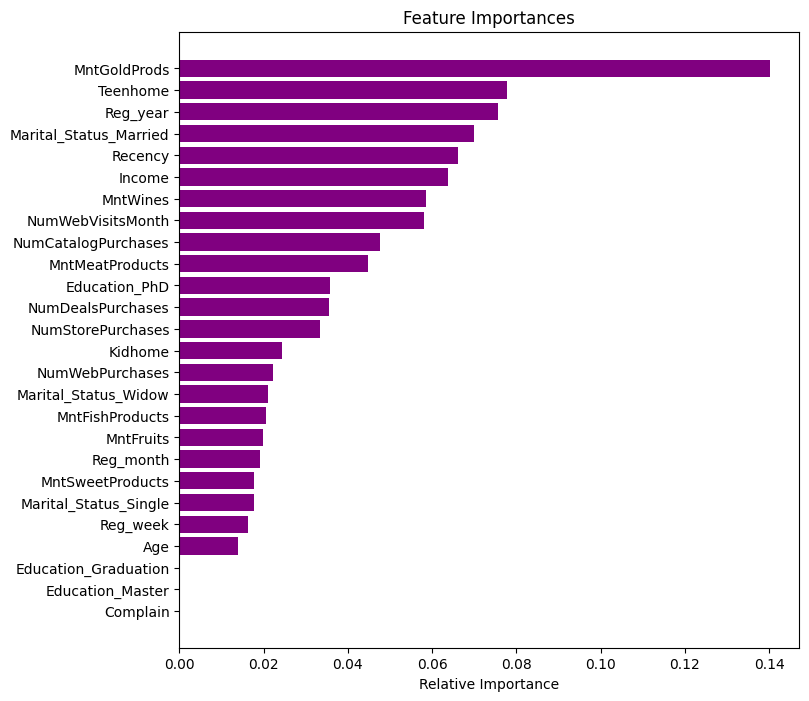

In [51]:
feature_names = X_train.columns
importances = xgb_tuned2.feature_importances_
indices = np.argsort(importances)

plt.figure(figsize=(8, 8))
plt.title("Feature Importances")
plt.barh(range(len(indices)), importances[indices], color="purple", align="center")
plt.yticks(range(len(indices)), [feature_names[i] for i in indices])
plt.xlabel("Relative Importance")
plt.show()

### ***Pipelines for productionizing the model*** 

***Pipeline is a means of automating the machine learning workflow by enabling data to be transformed and correlated into a model that can then be analyzed to achieve outputs. This type of ML pipeline makes the process of inputting data into the ML model fully automated.***

***`Column transformer` allows different columns or column subsets of the input to be transformed separately and the features generated by each transformer will be concatenated to form a single feature space. This is useful for heterogeneous or columnar data, to combine several feature extraction mechanisms or transformations into a single transformer.***


***We will create 2 different pipelines:***

***`Numerical columns`: we will do missing value imputation as pre-processing.***<br>
***`Categorical columns`: we will do one hot encoding and missing value imputation as pre-processing***

***We are doing missing value imputation for the whole data, so that if there is any missing value in the data in future that can be taken care of.***

In [52]:
# creating a list of numerical variables
numerical_features = [
    "Income",
    "Kidhome",
    "Teenhome",
    "Recency",
    "MntWines",
    "MntFruits",
    "MntMeatProducts",
    "MntFishProducts",
    "MntSweetProducts",
    "MntGoldProds",
    "NumDealsPurchases",
    "NumWebPurchases",
    "NumCatalogPurchases",
    "NumStorePurchases",
    "NumWebVisitsMonth",
    "Complain",
    "Age",
    "Reg_year",
    "Reg_month",
    "Reg_week",
]

# creating a transformer for numerical variables, which will apply simple imputer on the numerical variables
numeric_transformer = Pipeline(steps=[("imputer", SimpleImputer(strategy="median"))])


# creating a list of categorical variables
categorical_features = ["Education", "Marital_Status"]

# creating a transformer for categorical variables, which will first apply simple imputer and 
#then do one hot encoding for categorical variables
categorical_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore")),
    ]
)
# handle_unknown = "ignore", allows model to handle any unknown category in the test data

# combining categorical transformer and numerical transformer using a column transformer

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numerical_features),
        ("cat", categorical_transformer, categorical_features),
    ],
    remainder="passthrough",
)
# remainder = "passthrough" has been used, it will allow variables that are present in original data 
# but not in "numerical_columns" and "categorical_columns" to pass through the column transformer without any changes

In [53]:
# Separating target variable and other variables
X = data1.drop(columns="Response")
Y = data1["Response"]

In [54]:
# Splitting the data into train and test sets
X_train, X_test, y_train, y_test = train_test_split(X, Y, test_size=0.30, random_state=1, stratify=Y)

print(X_train.shape, X_test.shape)

(1565, 22) (672, 22)


In [55]:
# Creating new pipeline with best parameters
model = Pipeline(
    steps=[
        ("pre", preprocessor),
        (
            "XGB",
            XGBClassifier(
                random_state=1,
                n_estimators=100,
                scale_pos_weight=5,
                subsample=0.9,
                learning_rate=0.02,
                gamma=3,
                eval_metric="logloss",
                reg_lambda=10,
                max_depth=4,
            ),
        ),
    ]
)
# Fit the model on training data
model.fit(X_train, y_train)

,steps,"[('pre', ...), ('XGB', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'passthrough'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [56]:
y_pred = model.predict(X_test)
recall = recall_score(y_test, y_pred)
print("Test Recall:", round(recall, 3))

confusion_matrix(y_test, y_pred)

Test Recall: 0.68


array([[471, 101],
       [ 32,  68]])